In [12]:
from __future__ import annotations
from pathlib import Path
import json
from typing import Dict, List
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np


def load_ct3_metrics(root: str | Path) -> Dict[str, Dict[float, List[float]]]:
    """
    Load ALL CT3 metrics from all k=*/metrics.json and return a fully sorted structure:

        {
            metric_name: {
                mu_value: [values sorted by k-index],
                ...
            },
            ...
        }

    Sorting order:
        1) metric name (alphabetical)
        2) μ (ascending)
        3) values list sorted in k order
    """
    root = Path(root)

    # Temporary: μ → metric → {k: value}
    tmp = defaultdict(lambda: defaultdict(dict))

    # detect k index from folder "k=3"
    def extract_k(k_dir: Path) -> int:
        try:
            return int(str(k_dir.name).split("=")[1])
        except:
            return -1

    # Read all k=*
    for k_dir in root.glob("k=*"):
        k = extract_k(k_dir)
        metrics_file = k_dir / "metrics.json"
        if not metrics_file.exists():
            continue

        with metrics_file.open("r", encoding="utf-8") as f:
            data = json.load(f)

        metrics_per_mu = data.get("metrics_per_mu", {})
        for mu_str, mdict in metrics_per_mu.items():
            mu = float(mu_str)
            for metric_name, val in mdict.items():
                tmp[mu][metric_name][k] = float(val)

    if not tmp:
        raise ValueError(f"No CT3 metrics found under {root}")

    # Now build sorted structure: metric → μ → sorted list of values
    final = defaultdict(dict)

    # collect all metric names
    all_metrics = sorted({m for mu in tmp for m in tmp[mu].keys()})

    for metric_name in all_metrics:
        # μ sorted ascending
        for mu in sorted(tmp.keys()):
            if metric_name not in tmp[mu]:
                continue
            # sort by k index
            k_sorted = sorted(tmp[mu][metric_name].keys())
            val_list = [tmp[mu][metric_name][k] for k in k_sorted]
            final[metric_name][mu] = val_list

    return dict(final)


In [23]:
# After running CT3 and getting 'summary'
root = "C:\\Users\\JanderM\\OneDrive - University of Twente\\Documents\\Github Repos\\WP3_eXplainable_and_Fair_AI\\IRP1\\Code\\ct3\\code\\results\\20251118-140903\\PredictionTask\\UCBBanditAgent\\LinearTrend"

# Example: plot directional accuracy vs μ
metrics =  load_ct3_metrics(root)
metrics

{'D_ham': {-0.5: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  -0.25: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  0.0: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  0.25: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  0.5: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]},
 'delta_p': {-0.5: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  -0.25: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  0.0: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  0.25: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  0.5: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]},
 'p_up': {-0.5: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
  -0.25: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
  0.0: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
  0.25: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
  0.5: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]}}

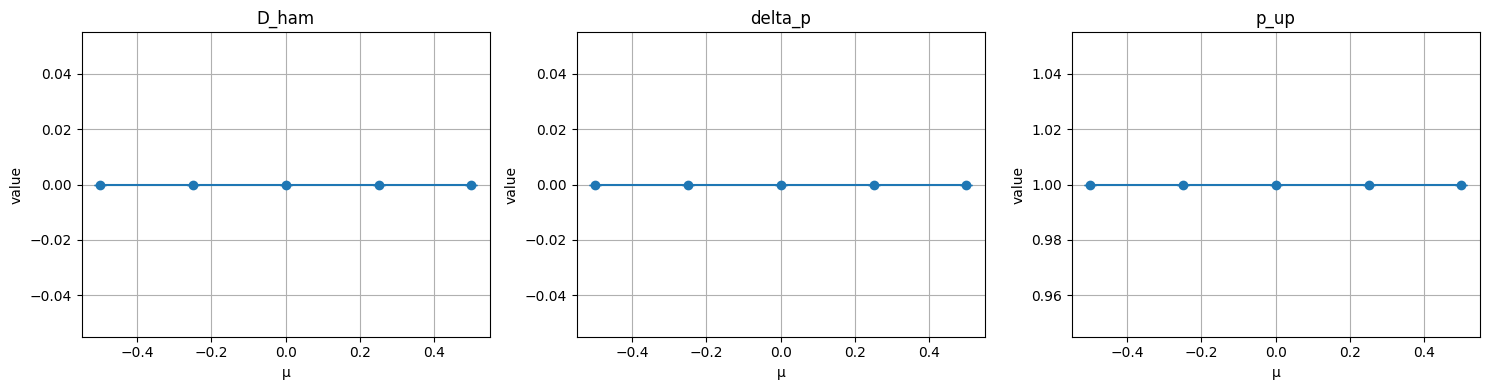

In [24]:
# --- Plot ---
num_metrics = len(metrics)
fig, axes = plt.subplots(1, num_metrics, figsize=(5 * num_metrics, 4), squeeze=False)
axes = axes[0]

for ax, (metric, mu_dict) in zip(axes, metrics.items()):
    mus = np.array(sorted(mu_dict.keys()))
    means = np.array([np.mean(mu_dict[mu]) for mu in mus])
    stds = np.array([np.std(mu_dict[mu]) for mu in mus])
    
    ax.errorbar(mus, means, yerr=stds, fmt='-o', capsize=4)
    ax.set_title(metric)
    ax.set_xlabel("μ")
    ax.set_ylabel("value")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [25]:
from pathlib import Path
import json

def load_training_log(root: str | Path):
    """
    Load `training_task_log.json` from the CT3 experiment root.

    Parameters
    ----------
    root : str | Path
        Path to the CT3 experiment root directory, e.g.:

        results/20251118-135844/

        or the deeper folder:

        results/20251118-135844/PredictionTask/Agent/Generator/

        In both cases, this function walks upward until it finds
        `training_task_log.json`.

    Returns
    -------
    log : Any
        Parsed JSON content (usually a list of dicts).
    """
    root = Path(root)

    # If user passed a deep folder like .../PredictionTask/Agent/Generator
    # climb upward until training_task_log.json appears.
    current = root
    training_path = None

    while current != current.parent:
        candidate = current / "training_task_log.json"
        if candidate.exists():
            training_path = candidate
            break
        current = current.parent

    if training_path is None:
        raise FileNotFoundError(
            f"training_task_log.json not found above {root}"
        )

    with training_path.open("r", encoding="utf-8") as f:
        return json.load(f)


In [28]:
train_log = load_training_log(root)

print(len(train_log),train_log[:3])

1000 [{'t': 1, 'value_prev': 0.0, 'value': 9.880821445482871, 'bet': 0, 'received_reward': -1, 'reward_cum': -1}, {'t': 2, 'value_prev': 9.880821445482871, 'value': 10.3444513937147, 'bet': 1, 'received_reward': 1, 'reward_cum': 0}, {'t': 3, 'value_prev': 10.3444513937147, 'value': 10.930567695218357, 'bet': 1, 'received_reward': 1, 'reward_cum': 1}]


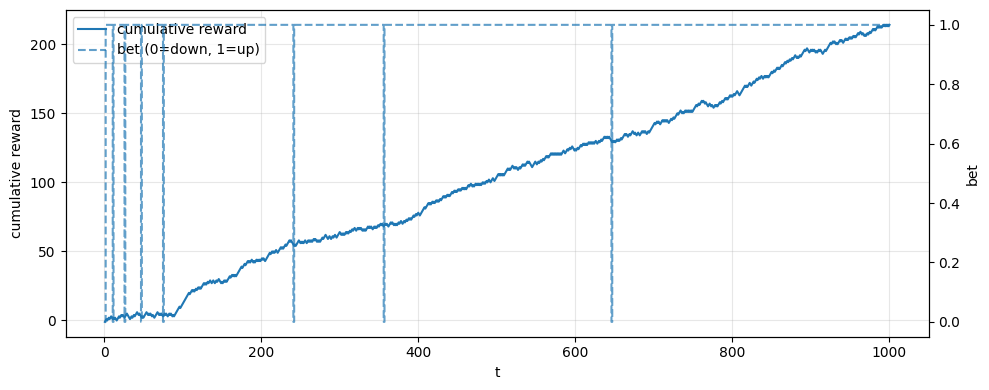

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def plot_reward_and_bets(task_log):
    # Extract series
    t = np.array([step["t"] for step in task_log], dtype=int)
    reward_cum = np.array([step["reward_cum"] for step in task_log], dtype=float)
    bets = np.array([step["bet"] for step in task_log], dtype=int)

    fig, ax1 = plt.subplots(figsize=(10, 4))

    # --- Cumulative reward ---
    ax1.plot(t, reward_cum, label="cumulative reward")
    ax1.set_xlabel("t")
    ax1.set_ylabel("cumulative reward")
    ax1.grid(True, which="both", axis="both", alpha=0.3)

    # --- Bets (0/1) on secondary axis ---
    ax2 = ax1.twinx()
    ax2.step(t, bets, where="post", linestyle="--", alpha=0.7, label="bet (0=down, 1=up)")
    ax2.set_ylabel("bet")

    # Combined legend
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="best")

    plt.tight_layout()
    plt.show()

# Example call:
plot_reward_and_bets(train_log)


We can see that agents upward actions (bets) and cumulative return align with the linear trend generator with positive drift. So the agent performs well on this functional form and parameter (treated as resulting in a fixed distribution) so it displays distributional learning ability. When looking at the CT3 plot we see that the policy is not sensitive to changes in the drift parameter. We predict that the task log of negative drift runs will show worse returns than the training log.

In [41]:
from __future__ import annotations
from pathlib import Path
import json
from typing import Dict, List


def load_task_logs_for_mu(
    root: str | Path,
    mu: float,
) -> Dict[int, List[dict]]:
    """
    Load all task logs for a specific μ from CT3 results.

    Expected filename format:
        task_logs[<mu>].json

    Example:
        k=0/task_logs[-0.5].json

    Parameters
    ----------
    root : str | Path
        The CT3 path ending at the generator folder, e.g.:

        results/.../PredictionTask/UCBBanditAgent/LinearTrend

    mu : float
        The μ value for which to load logs (must match string inside brackets).

    Returns
    -------
    logs_by_k : dict[int, list[dict]]
        Maps k-index → list of task log entries.

    Raises
    ------
    FileNotFoundError if no logs found for the given μ.
    """

    root = Path(root)
    logs_by_k = {}

    # μ string exactly as used in filenames
    mu_str = str(mu)

    # filename pattern
    filename = f"task_logs[{mu_str}].json"

    for k_dir in root.glob("k=*"):
        try:
            k = int(k_dir.name.split("=")[1])
        except Exception:
            continue

        file_path = k_dir / filename
        if not file_path.exists():
            continue

        with file_path.open("r", encoding="utf-8") as f:
            logs = json.load(f)

        logs_by_k[k] = logs

    if not logs_by_k:
        raise FileNotFoundError(
            f"No logs found for μ={mu} under: {root}"
        )

    return logs_by_k


In [42]:
root = "../results/20251118-140903/PredictionTask/UCBBanditAgent/LinearTrend"
mu = -0.5

logs = load_task_logs_for_mu(root, mu)

for k, log in logs.items():
    print("k=", k, "entries:", len(log))


k= 0 entries: 1000
k= 1 entries: 1000
k= 2 entries: 1000
k= 3 entries: 1000
k= 4 entries: 1000
k= 5 entries: 1000
k= 6 entries: 1000
k= 7 entries: 1000


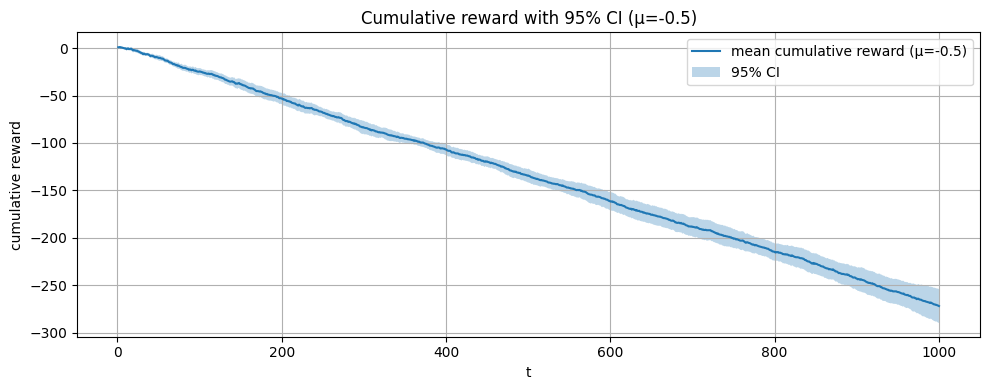

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Optional


def plot_reward_curves_with_ci_from_logs(
    logs_by_k: Dict[int, List[dict]],
    mu: Optional[float] = None,
) -> None:
    """
    Plot mean cumulative reward with 95% CI across noise paths, given
    a dict of task logs per k.

    Parameters
    ----------
    logs_by_k : dict[int, list[dict]]
        Maps k-index → list of log entries. Each entry should have
        either:
          - "reward_cum"  : cumulative reward up to that step, or
          - "received_reward" : per-step reward (then cumulated here)
        Optionally "t" for the time index.
    mu : float, optional
        If provided, used only for plot labeling.
    """
    if not logs_by_k:
        raise ValueError("logs_by_k is empty.")

    ks = sorted(logs_by_k.keys())
    # Use the minimum horizon across paths in case lengths differ
    T = min(len(logs_by_k[k]) for k in ks)
    K = len(ks)

    rewards_cum = np.zeros((K, T), dtype=float)

    for i, k in enumerate(ks):
        log = logs_by_k[k][:T]

        if "reward_cum" in log[0]:
            rewards_cum[i, :] = [step["reward_cum"] for step in log]
        else:
            # reconstruct cumulative reward from received_reward
            cum = 0.0
            tmp = []
            for step in log:
                cum += float(step.get("received_reward", 0.0))
                tmp.append(cum)
            rewards_cum[i, :] = tmp

    # Time axis
    first_log = logs_by_k[ks[0]][:T]
    if "t" in first_log[0]:
        t = np.array([step["t"] for step in first_log], dtype=int)
    else:
        t = np.arange(1, T + 1)

    # Mean + 95% CI
    mean_cum = rewards_cum.mean(axis=0)
    std_cum = rewards_cum.std(axis=0, ddof=1) if K > 1 else np.zeros_like(mean_cum)
    se_cum = std_cum / np.sqrt(K) if K > 0 else std_cum
    ci95 = 1.96 * se_cum

    plt.figure(figsize=(10, 4))
    label = "mean cumulative reward"
    if mu is not None:
        label += f" (μ={mu})"

    plt.plot(t, mean_cum, label=label)
    plt.fill_between(t, mean_cum - ci95, mean_cum + ci95, alpha=0.3, label="95% CI")
    plt.xlabel("t")
    plt.ylabel("cumulative reward")
    plt.title("Cumulative reward with 95% CI" + (f" (μ={mu})" if mu is not None else ""))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_reward_curves_with_ci_from_logs(logs, mu=-0.5)








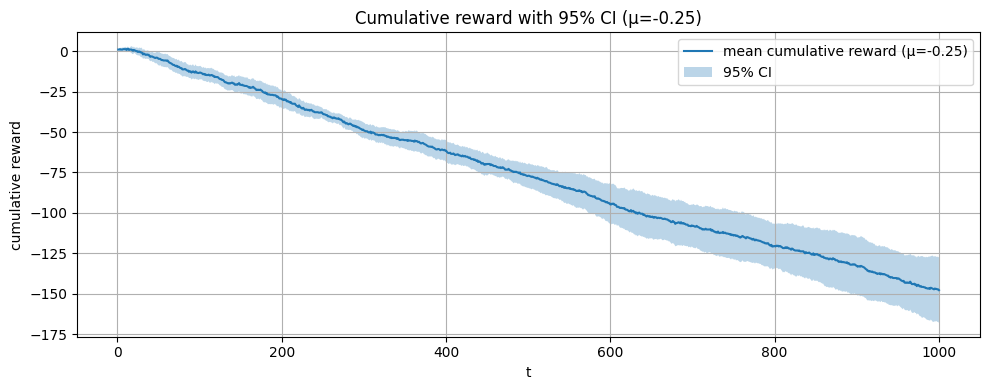

In [45]:
logs_by_k = load_task_logs_for_mu(root, mu=-0.25)
plot_reward_curves_with_ci_from_logs(logs_by_k, mu=-0.25)

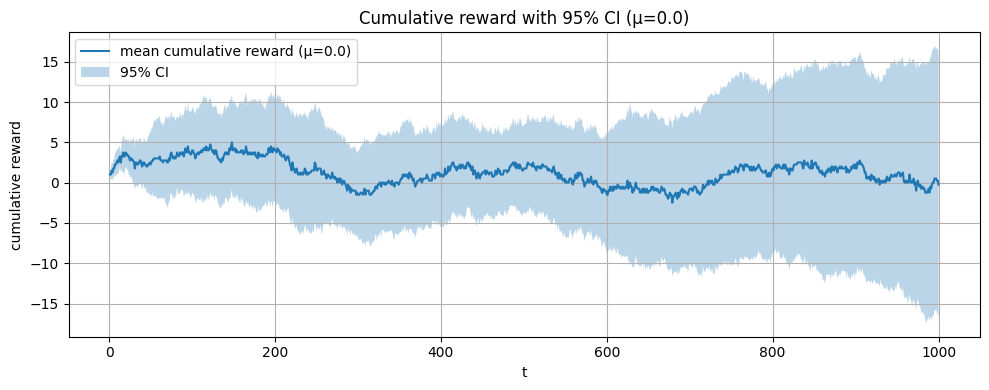

In [46]:
logs_by_k = load_task_logs_for_mu(root, mu=0.0)
plot_reward_curves_with_ci_from_logs(logs_by_k, mu=0.0)

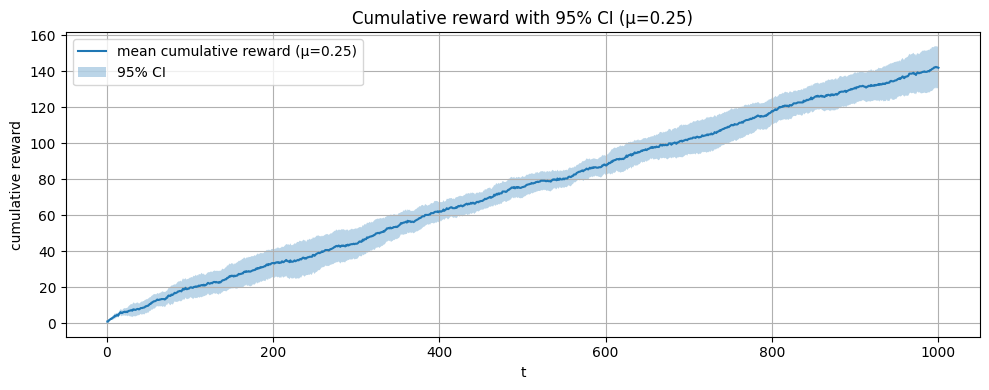

In [47]:
logs_by_k = load_task_logs_for_mu(root, mu=0.25)
plot_reward_curves_with_ci_from_logs(logs_by_k, mu=0.25)

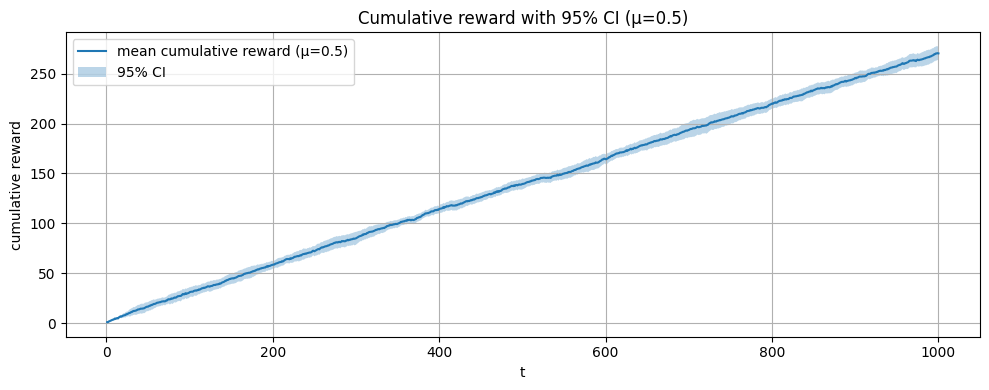

In [48]:
logs_by_k = load_task_logs_for_mu(root, mu=0.5)
plot_reward_curves_with_ci_from_logs(logs_by_k, mu=0.5)

We can see that cumulative reward for counterfactuals with negative drift is negative and hovering around mean for no drift (as there is no signal, just noise), while positive reward drift values (as during training phase) lead to positive cumulative rewards. This aligns with our prediction above. The trained policy seems to only have learned the distribution of actions (more likely to pick up than down) based on the generator's functional form and fixed parameter rather than learning the mechanistic relationship of the drift parameter and actions. This might be due to the UCBBanditAgent only looking at actions and lacking the ability to estimate parameters. Contextual bandits might allow to overcome this limitation if the context captures the drift parameter and maps its relationship to actions.


We are also able to show that in this case the CT3 metrics indicating no causal sensitivity to parameter variation predicts this policies inability to sustain cumulative reward under parameter variation.